# Visualization of the extracted features

## Preparation

In [1]:
import torch
from torch.utils.data import DataLoader, Subset
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from utils.train_utils.dataset import LPBSDataset
from models.utils.cnn_features_extractor import CNNFeatureExtractor
from models.model_regression import CNNBiLSTMMLPRegressor


Using PyTorch features: ['X', 'Y', 'ComputedSpeed_frames', 'Lifetime']


In [2]:
pytorch_dir = "../preprocessed_with_lifespan_no_crit"

In [3]:
scaler_config_path = os.path.join(pytorch_dir, "scaler_config.json")

# Load the dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset = LPBSDataset(
    pytorch_dir, 
    scaler_type="standard", 
    mode="train", 
    scaler_config_path=scaler_config_path,
    device=device
)

train_loader = DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=True
)

Loading Data:  78%|███████▊  | 72/92 [00:18<00:06,  3.22it/s]c:\Users\elrbe\all_code\flep\ML\project-2-astiflop\utils\train_utils\dataset.py:520: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Loading Data: 100%|██████████| 92/92 [00:23<00:00,  3.94it/s]


Scaler statistics saved to ../preprocessed_with_lifespan_no_crit\scaler_config.json
Applied standard normalization.


In [4]:
model_path = "../ckpts/nocrit_time.pth"

model = CNNBiLSTMMLPRegressor(
        segment_len=900,
        embed_dim=64,
        dropout=0,
        feature_extractor_layers=3,
        bilstm_layers=1,
        use_time_encoding=True
    ).to(device)
    
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded: {model_path}")
else:
    print(f"Warning: Model not found at {model_path}.")

model.eval()

[WARNING] Model: Time encoding enabled. Ensure presence of Lifetime feature and that max_time is set appropriately for the scale of Lifetime values.
Loaded: ../ckpts/nocrit_time.pth


CNNBiLSTMMLPRegressor(
  (feature_extractors): ModuleList(
    (0-2): 3 x CNNFeatureExtractor(
      (conv1): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
      (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
      (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(2,), padding=(1,))
      (global_pool): AdaptiveMaxPool1d(output_size=1)
      (fc): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (cnn_aggregation): Linear(in_features=192, out_features=64, bias=True)
  (variate_attention): GatedAttention(
    (attention_V): Sequential(
      (0): Linear(in_features=64, out_features=16, bias=True)
      (1): Tanh()
    )
    (attention_U): Sequential(
      (0): Linear(in_features=64, out_features=16, bias=True)
      (1): Sigmoid()
    )
    (attention_weights): Linear(in_features=16, out_features=1, bias=True)
  )
  (bilstms): ModuleList(
    (0): LSTM(64, 32, batch_first=True, bidirectional=True)
  )
  (lstm_aggregation): Linear(in_featu

## Pass accross the samples

In [5]:
# === 1. Extract Features (One pass over batches) ===
import numpy as np
import torch

all_features_sample = []
all_lifetimes_sample = []

all_features_time = []
all_lifetimes_time = []

model.eval()
with torch.no_grad():
    for i, (batch, _, lifetime) in enumerate(train_loader):
        batch = batch.to(device)
        B, T, V, L = batch.shape
        V_feat = V - 1

        x_features = batch[:, :, :-1, :]
        x_reshaped = x_features.reshape(B * T * V_feat, 1, L)

        extracted_features = []
        for fe in model.feature_extractors:
            extracted_features.append(fe(x_reshaped))
            
        features_cat = torch.cat(extracted_features, dim=-1)
        features_agg = model.cnn_aggregation(features_cat)
        
        # Base representation shape: (B, T, V_feat, embed_dim)
        features = features_agg.view(B, T, V_feat, model.embed_dim)
        
        # --- A. Sample Level (mean across T and V_feat) ---
        features_mean_sample = features.mean(dim=(1, 2))
        
        all_features_sample.append(features_mean_sample.cpu().numpy())
        all_lifetimes_sample.append(lifetime.cpu().numpy())
        
        # --- B. Time Segment Level (mean across V_feat only) ---
        features_mean_v = features.mean(dim=2) # (B, T, embed_dim)
        features_flat_time = features_mean_v.view(B * T, model.embed_dim)
        expanded_lifetimes_time = lifetime.repeat_interleave(T)
        
        # Subsample time segments to keep memory/UMAP speed reasonable (e.g. 50%)
        num_points = B * T
        subset_size = int(num_points * 0.5)
        indices = torch.randperm(num_points)[:subset_size]
        
        all_features_time.append(features_flat_time[indices].cpu().numpy())
        all_lifetimes_time.append(expanded_lifetimes_time[indices].cpu().numpy())

# Numpy Arrays
features_sample_np = np.concatenate(all_features_sample, axis=0)
lifetimes_sample_np = np.concatenate(all_lifetimes_sample, axis=0)

features_time_np = np.concatenate(all_features_time, axis=0)
lifetimes_time_np = np.concatenate(all_lifetimes_time, axis=0)

print(f"Total Sample-level points: {features_sample_np.shape[0]}")
print(f"Total Time-segment points: {features_time_np.shape[0]}")

Total Sample-level points: 92
Total Time-segment points: 6900


## Plot of the decomposition at the sample level

c:\Users\elrbe\all_code\flep\ML\project-2-astiflop\astiflop_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


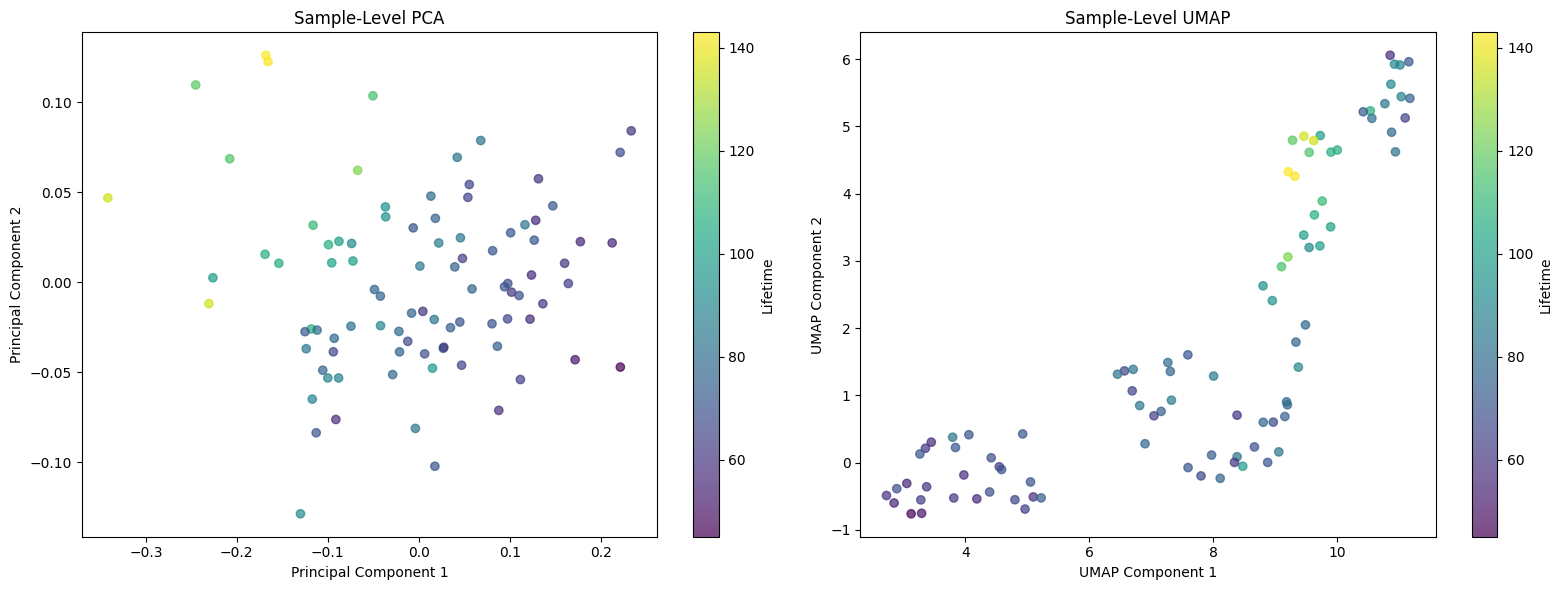

In [6]:
# === 2. Sample-Level Visualization ===
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

# A. Sample-Level PCA
pca_sample = PCA(n_components=2)
features_pca_sample = pca_sample.fit_transform(features_sample_np)

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_pca_sample[:, 0], features_pca_sample[:, 1], c=lifetimes_sample_np, cmap='viridis', alpha=0.7)
plt.colorbar(scatter1, label="Lifetime")
plt.title("Sample-Level PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# B. Sample-Level UMAP
reducer_sample = umap.UMAP(n_components=2)
features_umap_sample = reducer_sample.fit_transform(features_sample_np)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_umap_sample[:, 0], features_umap_sample[:, 1], c=lifetimes_sample_np, cmap='viridis', alpha=0.7)
plt.colorbar(scatter2, label="Lifetime")
plt.title("Sample-Level UMAP")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.tight_layout()
plt.show()

## Plot of the decompisitions at the segment level

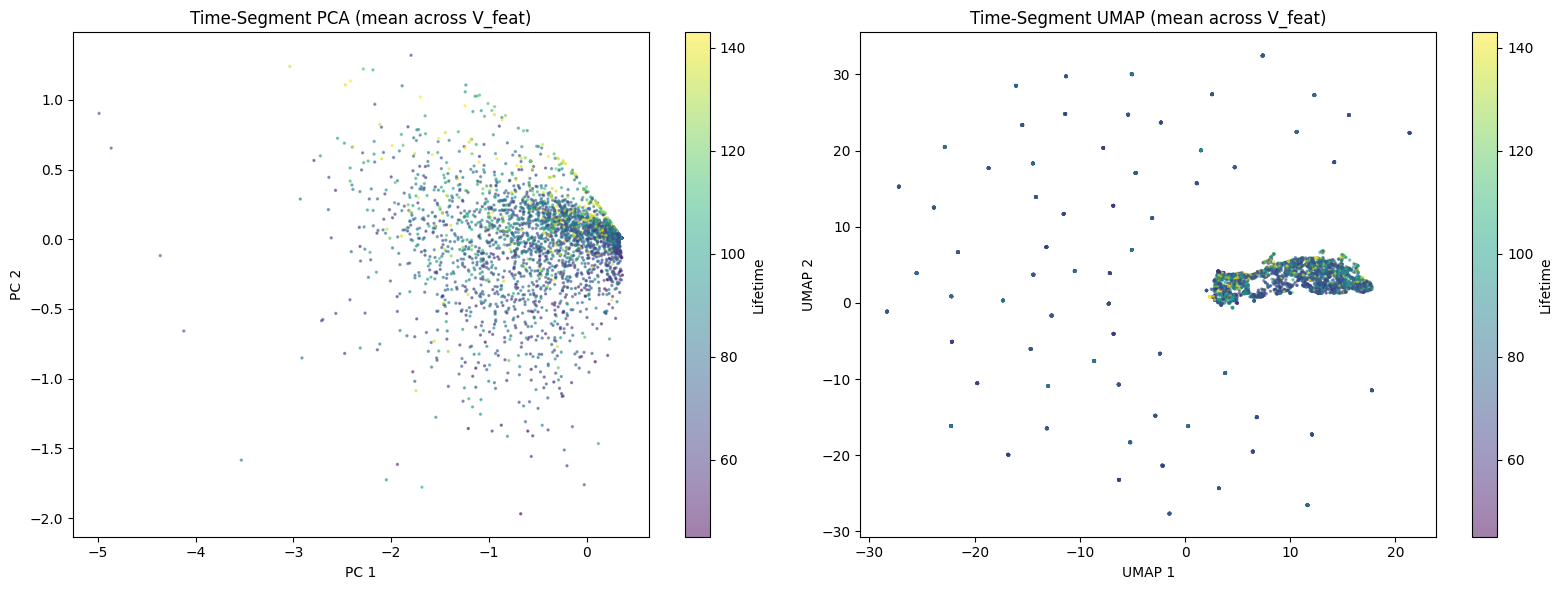

In [7]:
# === 3. Time Segment-Level Visualization ===
plt.figure(figsize=(16, 6))

# A. Time Segment-Level PCA
pca_time = PCA(n_components=2)
features_pca_time = pca_time.fit_transform(features_time_np)

plt.subplot(1, 2, 1)
scatter_pca_time = plt.scatter(features_pca_time[:, 0], features_pca_time[:, 1], c=lifetimes_time_np, cmap='viridis', alpha=0.5, s=2)
plt.colorbar(scatter_pca_time, label="Lifetime")
plt.title("Time-Segment PCA (mean across V_feat)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

# B. Time Segment-Level UMAP
reducer_time = umap.UMAP(n_components=2)
features_umap_time = reducer_time.fit_transform(features_time_np)

plt.subplot(1, 2, 2)
scatter_umap_time = plt.scatter(features_umap_time[:, 0], features_umap_time[:, 1], c=lifetimes_time_np, cmap='viridis', alpha=0.5, s=2)
plt.colorbar(scatter_umap_time, label="Lifetime")
plt.title("Time-Segment UMAP (mean across V_feat)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

## Plot of the embeddings at the staircase level

Total Staircase points plotted: 528


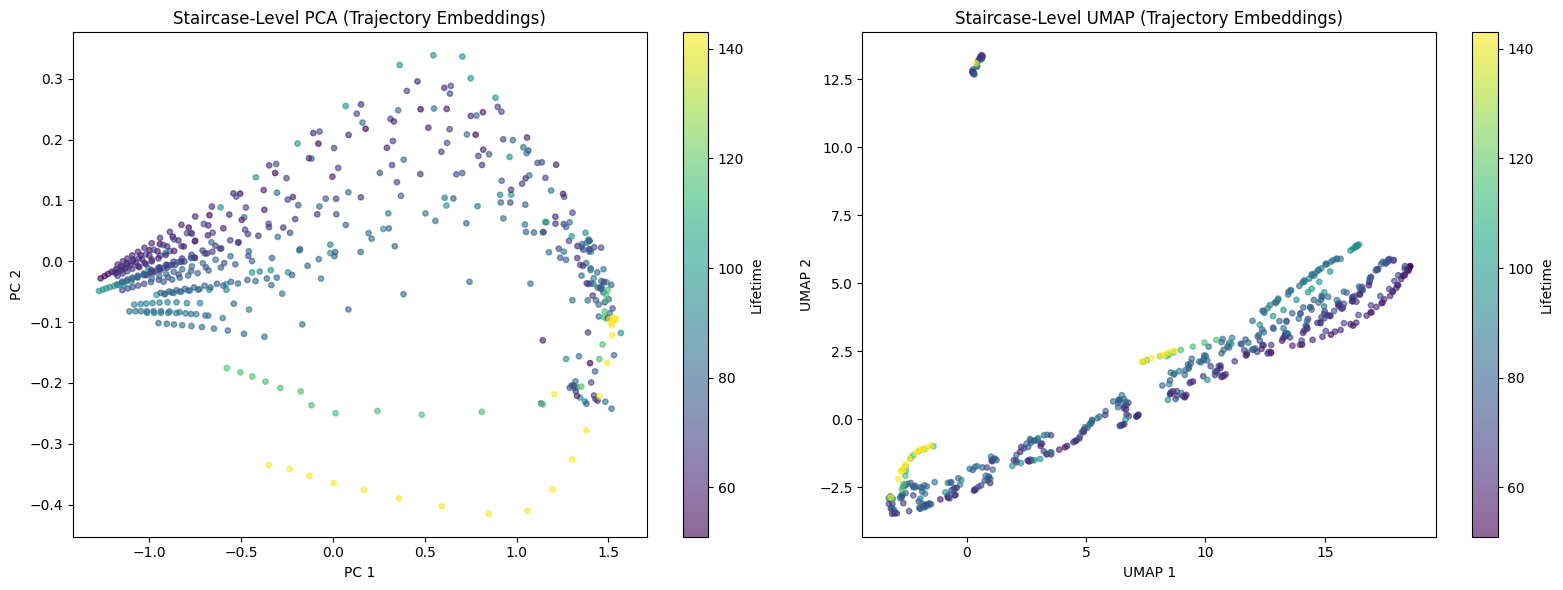

In [12]:
# === 4. Staircase-Level Visualization (Trajectory Embeddings) ===
# Here we visualize the embeddings of the full trajectory prefixes (staircases), 
# exactly as the regressor MLP receives them during training.
from torch.nn.utils.rnn import pad_sequence

all_staircase_embeddings = []
all_staircase_lifetimes = []

context_vectors = []
def hook(module, input):
    # input is a tuple. The first element is the input tensor to the regressor MLP.
    context_vectors.append(input[0].detach().cpu())

# Clear any existing pre-hooks (in case the cell was run multiple times)
model.regressor._forward_pre_hooks.clear()

# Register a forward pre-hook on the regressor to capture the final context vector
handle = model.regressor.register_forward_pre_hook(hook)

model.eval()
with torch.no_grad():
    for i, (batch, _, lifetime) in enumerate(train_loader):
        if i >= 3: # Limit to 3 batches (3 * 8 = 24 samples) to save time/memory
            break
            
        batch = batch.to(device)
        B, T, V, L = batch.shape
        
        X_staircase = []
        Y_lifetime = []
        
        for b_idx in range(B):
            full_trajectory = batch[b_idx] # Shape: (T, V, L)
            lt = lifetime[b_idx].item()
            
            # To avoid creating too many tensors, we sample steps along the trajectory (e.g., ~20 steps per sample)
            stride = max(1, T // 20)
            
            for t in range(1, T + 1, stride):
                
                # Make sure the last segment is always included
                if t + stride > T + 1:
                    t = T
                    
                X_staircase.append(full_trajectory[:t])
                Y_lifetime.append(lt)
                
        # Pad the staircase sequences so they can be processed in parallel
        X_padded = pad_sequence(X_staircase, batch_first=True).to(device)
        
        # Create attention mask matching the architecture logic in model_regression.py
        indices = torch.arange(X_padded.size(1), device=device).expand(len(X_staircase), -1)
        lengths_tensor = torch.tensor([len(x) for x in X_staircase], device=device).unsqueeze(1)
        mask = (indices < lengths_tensor).float()
        
        # Forward pass in chunks to avoid OOM (triggering the hook and populating `context_vectors`)
        chunk_size = 8
        for start_idx in range(0, X_padded.size(0), chunk_size):
            end_idx = min(start_idx + chunk_size, X_padded.size(0))
            _ = model(X_padded[start_idx:end_idx], mask=mask[start_idx:end_idx])
        
        all_staircase_lifetimes.extend(Y_lifetime)

# Remove the hook as it's no longer needed
handle.remove()

# The hook gathered the context tensors for each batch `i`
staircase_features_np = torch.cat(context_vectors, dim=0).numpy()
staircase_lifetimes_np = np.array(all_staircase_lifetimes)

print(f"Total Staircase points plotted: {staircase_features_np.shape[0]}")

# --- A. PCA ---
pca_staircase = PCA(n_components=2)
features_pca_staircase = pca_staircase.fit_transform(staircase_features_np)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
scatter_pca_staircase = plt.scatter(features_pca_staircase[:, 0], features_pca_staircase[:, 1], c=staircase_lifetimes_np, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter_pca_staircase, label="Lifetime")
plt.title("Staircase-Level PCA (Trajectory Embeddings)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

# --- B. UMAP ---
reducer_staircase = umap.UMAP(n_components=2)
features_umap_staircase = reducer_staircase.fit_transform(staircase_features_np)

plt.subplot(1, 2, 2)
scatter_umap_staircase = plt.scatter(features_umap_staircase[:, 0], features_umap_staircase[:, 1], c=staircase_lifetimes_np, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter_umap_staircase, label="Lifetime")
plt.title("Staircase-Level UMAP (Trajectory Embeddings)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()